Physical context: In chemical looping, the oxygen carrier alternates between reduction and oxidation repeatedly. Conversion X rises during reduction and falls during oxidation every cycle.

Chemical looping works in cycles. The solid oxygen carrier (like Fe₂O₃) gets reduced by fuel (X rises from 0→1), then gets re-oxidised by air (X falls from 1→0), then reduced again, and so on. You are modelling 3 complete cycles of this alternating process with one single PINN.

Governing ODEs

$$\frac{dX}{dt} = k_{red} (1 - X)^{2/3}$$

$$\frac{dX}{dt} = k_{oxd} X^{2/3}$$

Total Cycles: 3

Each Half-Cycle: 15 seconds

Time Domain: 90 seconds $t \in [0,90]$

Parameters: $k_{red} = 0.15 s^{-1}, \qquad k_{oxd} = 0.10 s^{-1} $

Cycle Boundaries: $t = [15, 30, 45, 60, 75]$

# **DeepXDE Implementation**

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt

# DeepXDE backend is fixed once dde is imported.
# If this still says 'tensorflow', the runtime might need a restart,
# but our new PDE code will handle both.
print(f"Current DeepXDE backend: {dde.backend.backend_name}")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Current DeepXDE backend: pytorch


In [3]:
# Defining the parameters
k_red = 0.15
k_oxd = 0.10

In [4]:
# Defining the time domain
t_max = 90
timedomain = dde.geometry.TimeDomain(0, t_max)

In [5]:
# Defining the pde using active backend primitives for compatibility
def pde(t, X):
    # Defining the derivative
    dX_dt = dde.grad.jacobian(X, t, i=0, j=0)

    # Phase time for cycles
    phase_time = t % 30

    # Get the active backend
    be = dde.backend

    # Use backend-agnostic power and relu for the kinetics
    r_red = k_red * be.pow(be.relu(1 - X) + 1e-6, 2/3)
    r_oxd = k_oxd * be.pow(be.relu(X) + 1e-6, 2/3)

    # Explicit switching logic using the specific backend's 'where'
    # This handles both PyTorch and TensorFlow types correctly
    if be.backend_name == "tensorflow":
        import tensorflow as tf
        rhs = tf.where(phase_time < 15, r_red, -r_oxd)
    else:
        import torch
        rhs = torch.where(phase_time < 15, r_red, -r_oxd)

    return dX_dt - rhs

In [6]:
# Defining the boudnary condition
def boundary(x, on_initial):
  return on_initial

# Boundary condition
bc = dde.icbc.IC(timedomain, lambda t:0.0, boundary)

In [7]:
boundary_cluster = []
for b in [15, 30, 45, 60, 75]:
    pts = np.linspace(b - 0.5, b + 0.5, 20).reshape(-1, 1)
    boundary_cluster.append(pts)

anchors = np.vstack(boundary_cluster)

data = dde.data.TimePDE(
    timedomain,
    pde,
    bc,
    num_domain=3000,
    num_boundary=2,
    num_test=500,
    anchors=anchors
)

In [8]:
# Re-initializing net and model with the updated data and PDE logic
net = dde.nn.FNN([1] + [64] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=1e-3)

# Train the model
losshistory, train_state = model.train(iterations=30000, display_every=5000)
model.compile("L-BFGS-B")
losshistory, train_state = model.train()

Compiling model...
'compile' took 16.641284 s

Training model...

Step      Train loss              Test loss               Test metric
0         [2.83e-02, 0.00e+00]    [2.82e-02, 0.00e+00]    []  
5000      [2.27e-04, 8.63e-07]    [1.58e-04, 8.63e-07]    []  
10000     [1.95e-04, 2.63e-07]    [1.58e-04, 2.63e-07]    []  
15000     [2.23e-04, 1.23e-07]    [1.86e-04, 1.23e-07]    []  
20000     [9.97e-05, 5.18e-06]    [6.20e-05, 5.18e-06]    []  
25000     [9.60e-05, 4.03e-09]    [6.49e-05, 4.03e-09]    []  
30000     [1.78e-04, 2.46e-06]    [8.34e-05, 2.46e-06]    []  

Best model at step 25000:
  train loss: 9.60e-05
  test loss: 6.49e-05
  test metric: []

'train' took 837.194938 s

Compiling model...
'compile' took 0.000474 s

Training model...

Step      Train loss              Test loss               Test metric
30000     [1.78e-04, 2.46e-06]    [8.34e-05, 2.46e-06]    []  

Best model at step 25000:
  train loss: 9.60e-05
  test loss: 6.49e-05
  test metric: []

'train' took 0.0

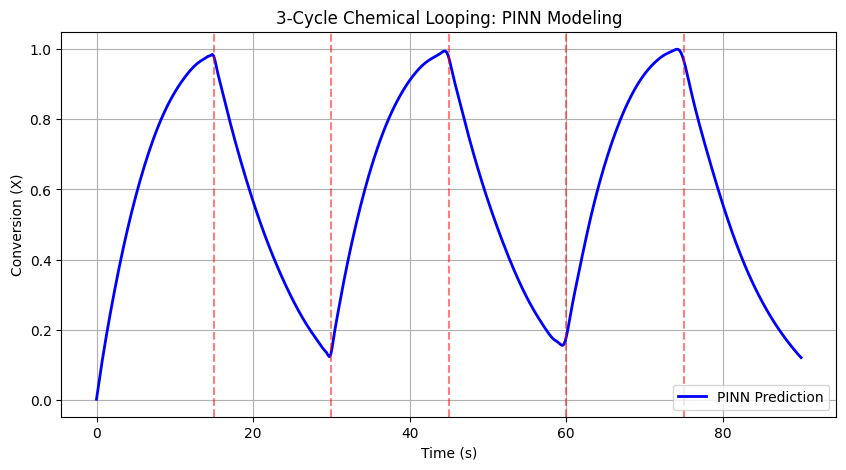

In [9]:
# Visualization of the results
t_eval = np.linspace(0, t_max, 500).reshape(-1, 1)
X_pred = model.predict(t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, X_pred, label="PINN Prediction", color="blue", lw=2)

# Adding cycle boundaries for clarity
for boundary in [15, 30, 45, 60, 75]:
    plt.axvline(x=boundary, color="red", linestyle="--", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Conversion (X)")
plt.title("3-Cycle Chemical Looping: PINN Modeling")
plt.legend()
plt.grid(True)
plt.show()

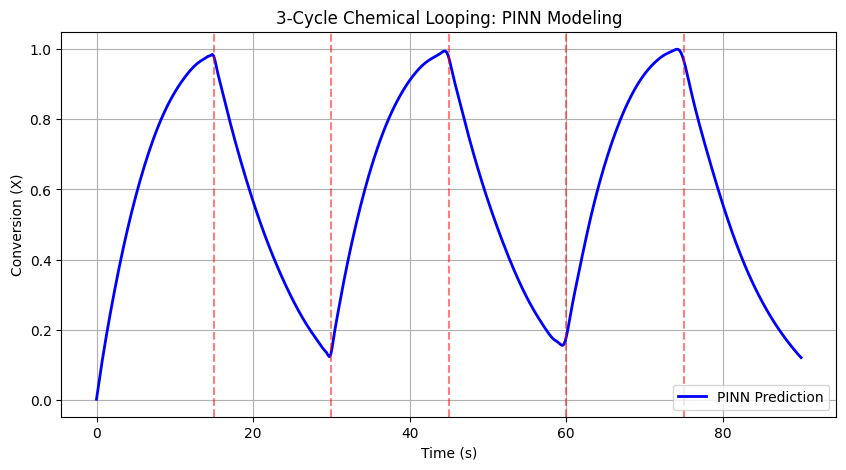

In [10]:
# Visualization of the results
t_eval = np.linspace(0, t_max, 500).reshape(-1, 1)
X_pred = model.predict(t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, X_pred, label="PINN Prediction", color="blue", lw=2)

# Adding cycle boundaries for clarity
for b in [15, 30, 45, 60, 75]:
    plt.axvline(x=b, color="red", linestyle="--", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Conversion (X)")
plt.title("3-Cycle Chemical Looping: PINN Modeling")
plt.legend()
plt.grid(True)
plt.show()

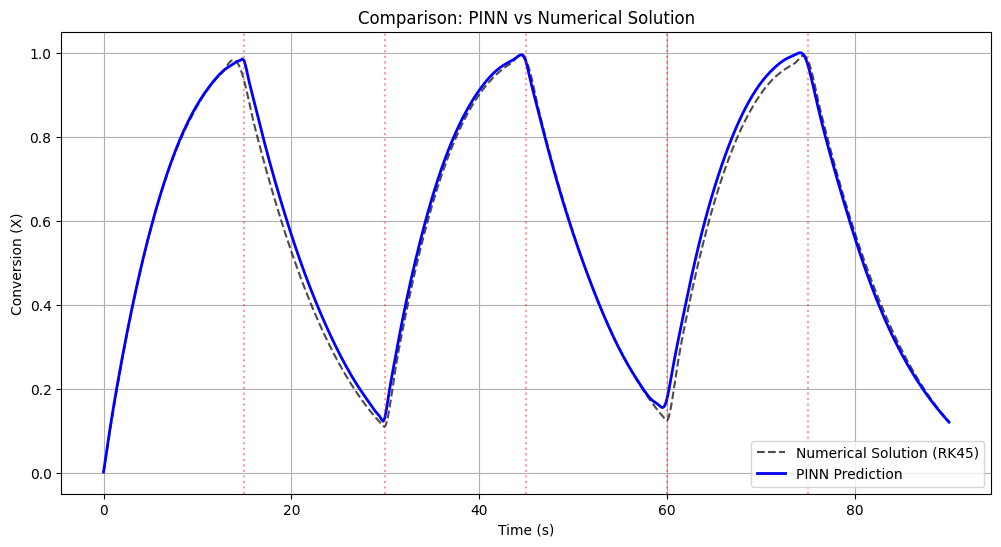

In [11]:
from scipy.integrate import solve_ivp

def numerical_ode(t, X):
    # Replicating the switching logic for the numerical solver
    phase_time = t % 30
    if phase_time < 15:
        # Reduction phase
        return k_red * (max(0, 1 - X))**(2/3)
    else:
        # Oxidation phase
        return -k_oxd * (max(0, X))**(2/3)

# Solve the ODE numerically
t_span = (0, t_max)
t_eval_num = np.linspace(0, t_max, 1000)
sol = solve_ivp(numerical_ode, t_span, [0.0], t_eval=t_eval_num, method='RK45')

# Visualization: PINN vs Numerical
plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[0], 'k--', label='Numerical Solution (RK45)', alpha=0.7)
plt.plot(t_eval, X_pred, 'b-', label='PINN Prediction', lw=2)

for b in [15, 30, 45, 60, 75]:
    plt.axvline(x=b, color='red', linestyle=':', alpha=0.4)

plt.xlabel('Time (s)')
plt.ylabel('Conversion (X)')
plt.title('Comparison: PINN vs Numerical Solution')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Interpolate PINN prediction to match numerical solution time steps for comparison
from scipy.interpolate import interp1d

# PINN prediction function
pinn_interp = interp1d(t_eval.flatten(), X_pred.flatten(), kind='cubic')
X_pinn_at_num_t = pinn_interp(sol.t)

# Calculate Error Metrics
mae = np.mean(np.abs(X_pinn_at_num_t - sol.y[0]))
rmse = np.sqrt(np.mean((X_pinn_at_num_t - sol.y[0])**2))
max_error = np.max(np.abs(X_pinn_at_num_t - sol.y[0]))

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Square Error (RMSE): {rmse:.6f}")
print(f"Maximum Absolute Error: {max_error:.6f}")

Mean Absolute Error (MAE): 0.016539
Root Mean Square Error (RMSE): 0.022209
Maximum Absolute Error: 0.068570


In [13]:
print("── Physics sanity checks ──────────────────────")
print(f"X min: {X_pred.min():.4f}  (must be >= 0)")
print(f"X max: {X_pred.max():.4f}  (must be <= 1)")

# Continuity at each boundary — no jumps
t_fine = np.linspace(0, 90, 9000)
X_fine = model.predict(t_fine.reshape(-1,1)).flatten()
for b in [15, 30, 45, 60, 75]:
    idx = np.argmin(np.abs(t_fine - b))
    left  = X_fine[max(0, idx-5):idx].mean()
    right = X_fine[idx:idx+5].mean()
    print(f"X continuity at t={b}s: left={left:.4f}, right={right:.4f}, jump={abs(right-left):.4f}")

── Physics sanity checks ──────────────────────
X min: 0.0016  (must be >= 0)
X max: 1.0002  (must be <= 1)
X continuity at t=15s: left=0.9809, right=0.9778, jump=0.0031
X continuity at t=30s: left=0.1336, right=0.1391, jump=0.0056
X continuity at t=45s: left=0.9784, right=0.9745, jump=0.0039
X continuity at t=60s: left=0.1750, right=0.1797, jump=0.0047
X continuity at t=75s: left=0.9718, right=0.9680, jump=0.0038
